In [79]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
svg_dir = '/Users/evillz/Data/CTC44/2025_12_03/svg_maps/'

### create map from fit parameters


In [80]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
svg_dir = '/Users/evillz/Data/CTC44/2025_12_03/svg_maps/'


In [81]:
# import shutil
# # Create a new folder for missing files
# missing_files_dir = os.path.join(map_path, 'missing_ting_fits')
# os.makedirs(missing_files_dir, exist_ok=True)
# print(f"Created directory: {missing_files_dir}")

# # Copy the missing files
# copied_count = 0
# error_count = 0

# for filepath in missing_files:
#     try:
#         if pd.notna(filepath) and os.path.exists(filepath):
#             # Get the filename from the full path
#             filename = os.path.basename(filepath)
            
#             # Create the destination path
#             dest_path = os.path.join(missing_files_dir, filename)
            
#             # Copy the file
#             shutil.copy2(filepath, dest_path)
#             # Also copy the .tdms_index file if it exists
#             index_filepath = filepath + "_index"
#             if os.path.exists(index_filepath):
#                 index_dest_path = dest_path + "_index"
#                 shutil.copy2(index_filepath, index_dest_path)
#             copied_count += 1
#         else:
#             print(f"File not found or invalid: {filepath}")
#             error_count += 1
#     except Exception as e:
#         print(f"Error copying {filepath}: {e}")
#         error_count += 1

# print(f"\nCopy complete:")
# print(f"  Successfully copied: {copied_count} files")
# print(f"  Errors: {error_count} files")
# print(f"  Destination: {missing_files_dir}")

In [82]:
path_ting = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results/w_felix/ting_changed_params_wFelix_ting_results.csv'
path_ting_stiff = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results/w_felix/ting_stiff_ting_results.csv'
map_path = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/'

map_name = os.path.basename(map_path.strip('/'))  

In [83]:
df_dict_tdms, map_x_pix, map_y_pix, params = maps.load_map_file_square_tdms(map_path)

# of files analyzed: 1024, closest shape: 32 x 32
 map metadata: map_x_step: 0.143, map_y_step: 0.143, map_x_init: 0.0, map_y_init: 0.0
 x_sens (um/V): 5.685, y_sens (um/V): 3.96, z_sens (um/V): 6.0, z_setpoint_trig (V): 7.60257


In [84]:
df_ting = pd.read_csv(path_ting)   
df_ting_stiff = pd.read_csv(path_ting_stiff)    

df_ting_merged = pd.merge(df_ting, df_ting_stiff, on=['file_id','file_path'], suffixes=('_old', '_stiff'))
df_final_ting = pd.merge(df_dict_tdms, df_ting_merged, on=['file_id'], how='left')

In [85]:
# Filter columns containing 'ting' AND 'E0' (both must be present)
df_final_ting.filter(regex='ting.*E0|E0.*ting').columns

Index(['ting_E0_old', 'ting_E0_stiff'], dtype='object')

In [86]:
# If ting_E0_old is 0 or NaN, use ting_E0_stiff; else use ting_E0_old
df_final_ting['ting_E0_mixed'] = np.where(
    (df_final_ting['ting_E0_old'] == 0)| np.isnan(df_final_ting['ting_E0_old']),
    df_final_ting['ting_E0_stiff'],
    df_final_ting['ting_E0_old']
)

df_final_ting['betaE_mixed'] = np.where(
    (df_final_ting['ting_betaE_old'] == 0)| np.isnan(df_final_ting['ting_betaE_old']),
    df_final_ting['ting_betaE_stiff'],
    df_final_ting['ting_betaE_old']
)

# Create numeric indicator (0 = old, 1 = stiff)
df_final_ting['E0_source_numeric'] = np.where(
    (df_final_ting['ting_E0_old'] == 0) | np.isnan(df_final_ting['ting_E0_old']),
    1,  # stiff
    0   # old
)



In [87]:
df_final_ting.filter(like = 'height').columns

Index(['z_height_v', 'z_height_um', 'z_height_um_zero',
       'hertz_sample_height_old', 'hertz_sample_height_stiff'],
      dtype='object')

In [88]:
df_final_ting.filter(like = 'betaE').columns

Index(['ting_betaE_old', 'ting_betaE_stiff', 'betaE_mixed'], dtype='object')

In [106]:
csv_file_path = '/Users/evillz/Data/article/csv_maps_article'
map_file_path = '/Users/evillz/Data/article/maps_svg'


Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: -0.3010299956639812, zmin: -1.9999999999994529
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/maps_svg/ting_betaE_old_psnex_map___2025.05.30_17.44.50.71.svg
Saving CSV for ting_betaE_old_psnex_map___2025.05.30_17.44.50.71.csv
Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: -0.3010299956639812, zmin: -1.9999999999998568
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/maps_svg/ting_betaE_stiff_psnex_map___2025.05.30_17.44.50.71.svg
Saving CSV for ting_betaE_stiff_psnex_map___2025.05.30_17.44.50.71.csv
Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: -0.3010299956639812, zmin: -1.9999999999994529
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/maps_svg/betaE_mixed_psnex_map___2025.05.30_17.44.50.71.svg
Saving CSV for betaE_mixed_psnex_map___2025.05.30_17.44.50.71.csv


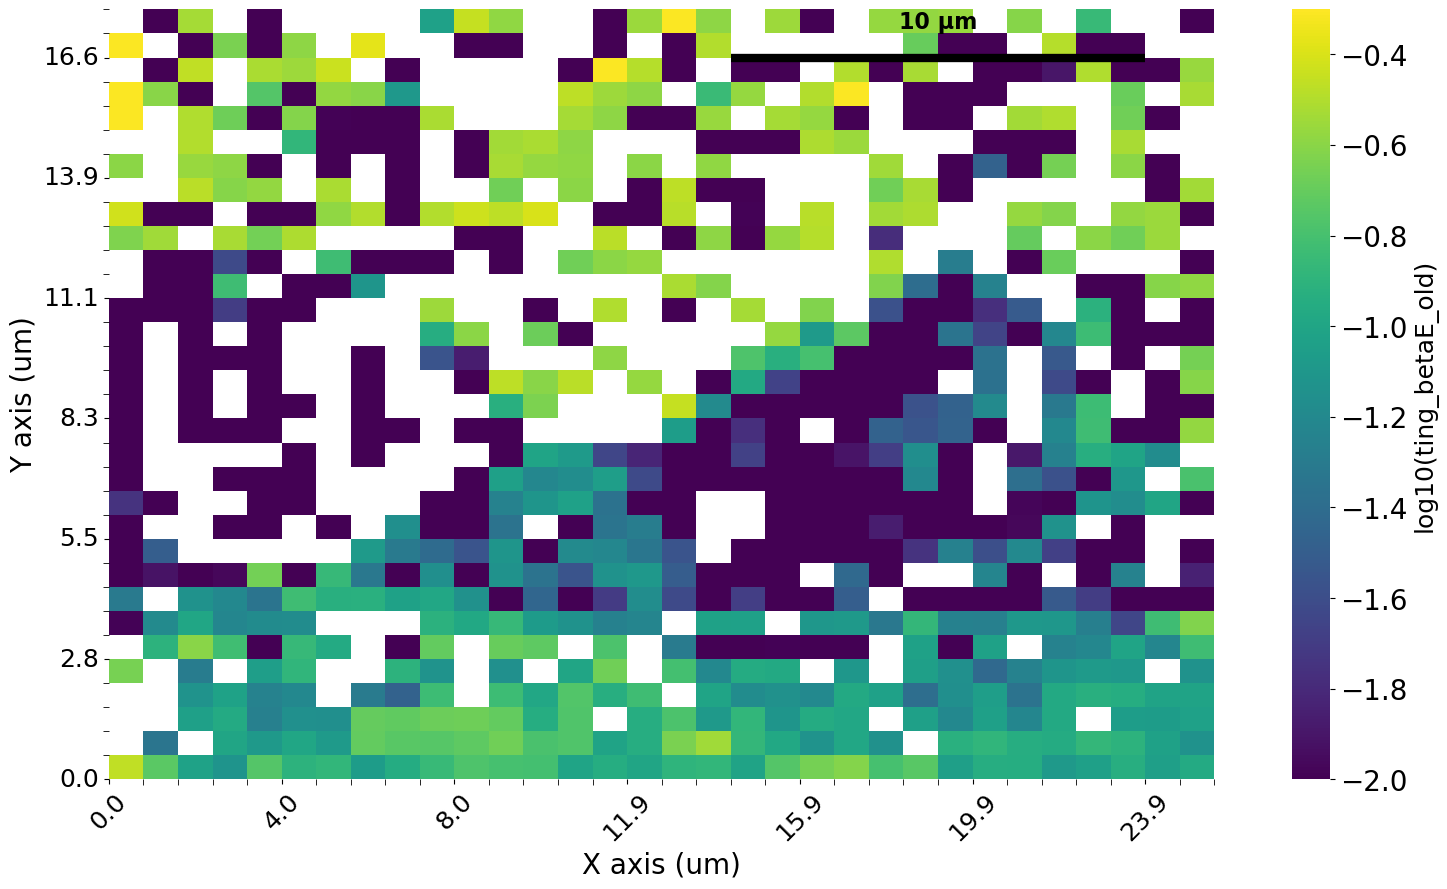

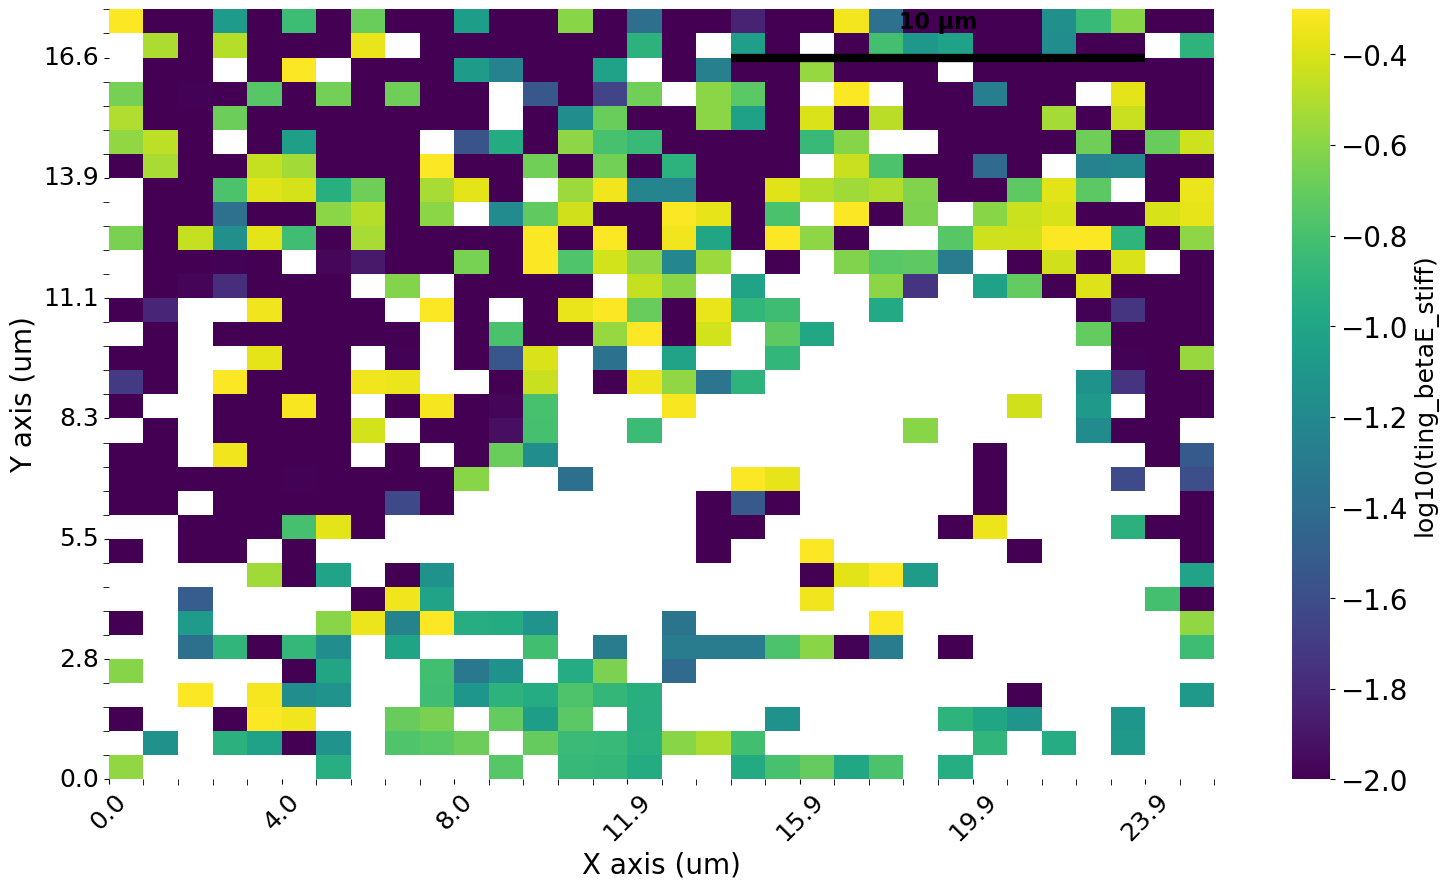

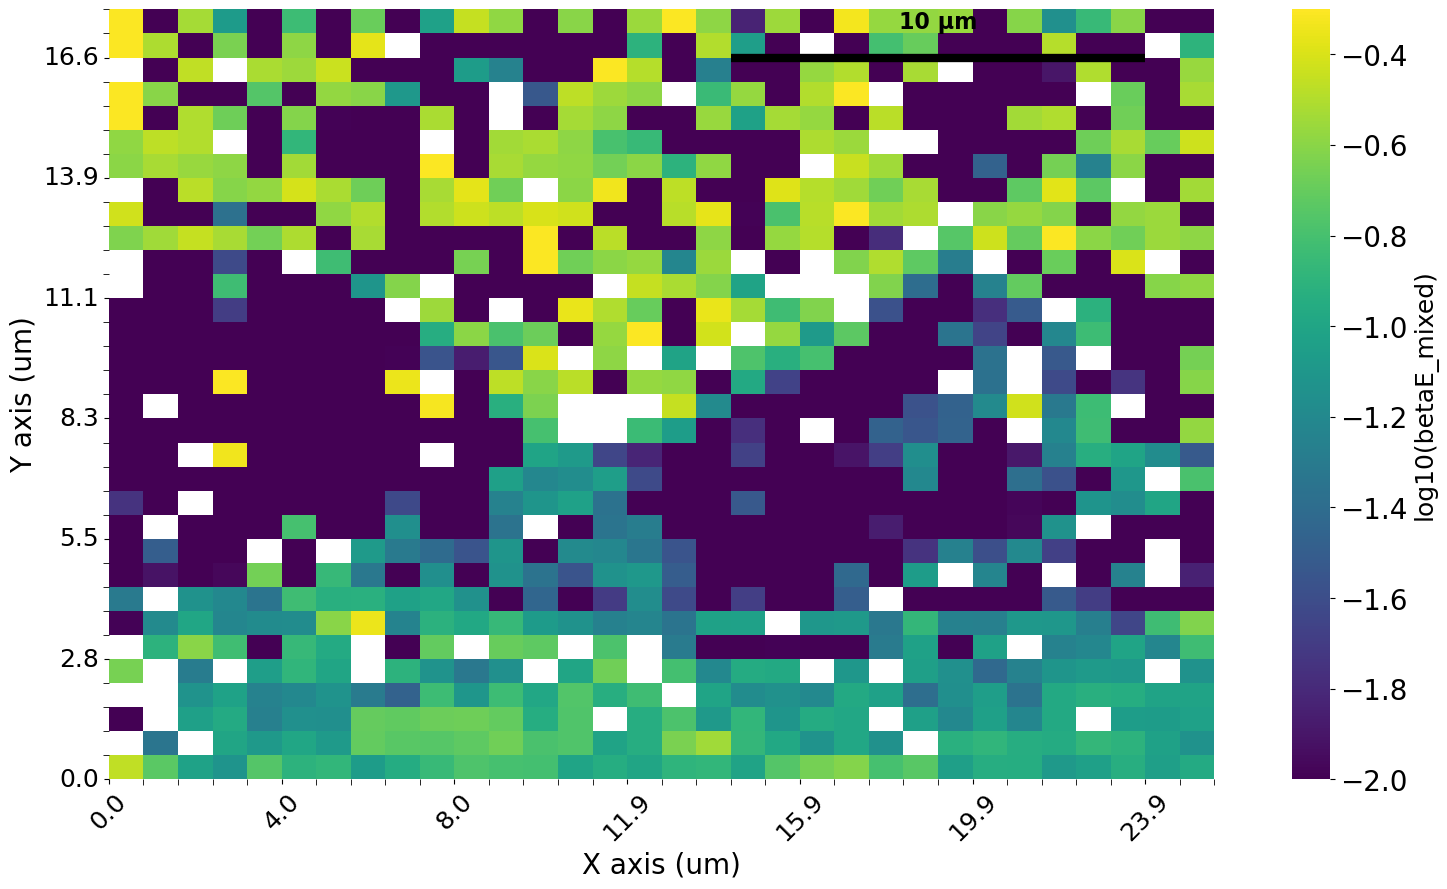

In [112]:

keys_list = ['ting_betaE_old', 'ting_betaE_stiff', 'betaE_mixed']
logscale = [True, True, True]
for key_combined, logscale_value in zip(keys_list, logscale):
    df_temp, _ , _ = maps.create_heatmap(df_final_ting, value_key=key_combined, annot=False,
                            save_svg=True, svg_path=os.path.join(map_file_path, f'{key_combined}_{map_name}.svg'),
                            cmap='viridis', nan=True, lastColFirst=False, logscale=logscale_value, scale_axis=True,
                            zmax = 0.5,)

    # save csv file for each map
    print (f'Saving CSV for {key_combined}_{map_name}.csv')

    # df_temp.to_csv(os.path.join(csv_file_path, f'{key_combined}_{map_name}.csv'), index=False)
    # # save corresponding dataframe as csv file with all rows and columsn from df_temp dataframe

                            

Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 6.124188461520605, zmin: 1.4272730766394324
y_sens_um: 3.96, x_sens_um: 5.685
Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 5.656285499805132, zmin: 1.4272730766394324
y_sens_um: 3.96, x_sens_um: 5.685
Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 6.362400386408812, zmin: 1.3081416675095008
y_sens_um: 3.96, x_sens_um: 5.685
Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 14.18737800000001, zmin: 0.0
y_sens_um: 3.96, x_sens_um: 5.685
Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: -0.30980392004824225, zmin: -1.9999999999994529
y_sens_um: 3.96, x_sens_um: 5.685


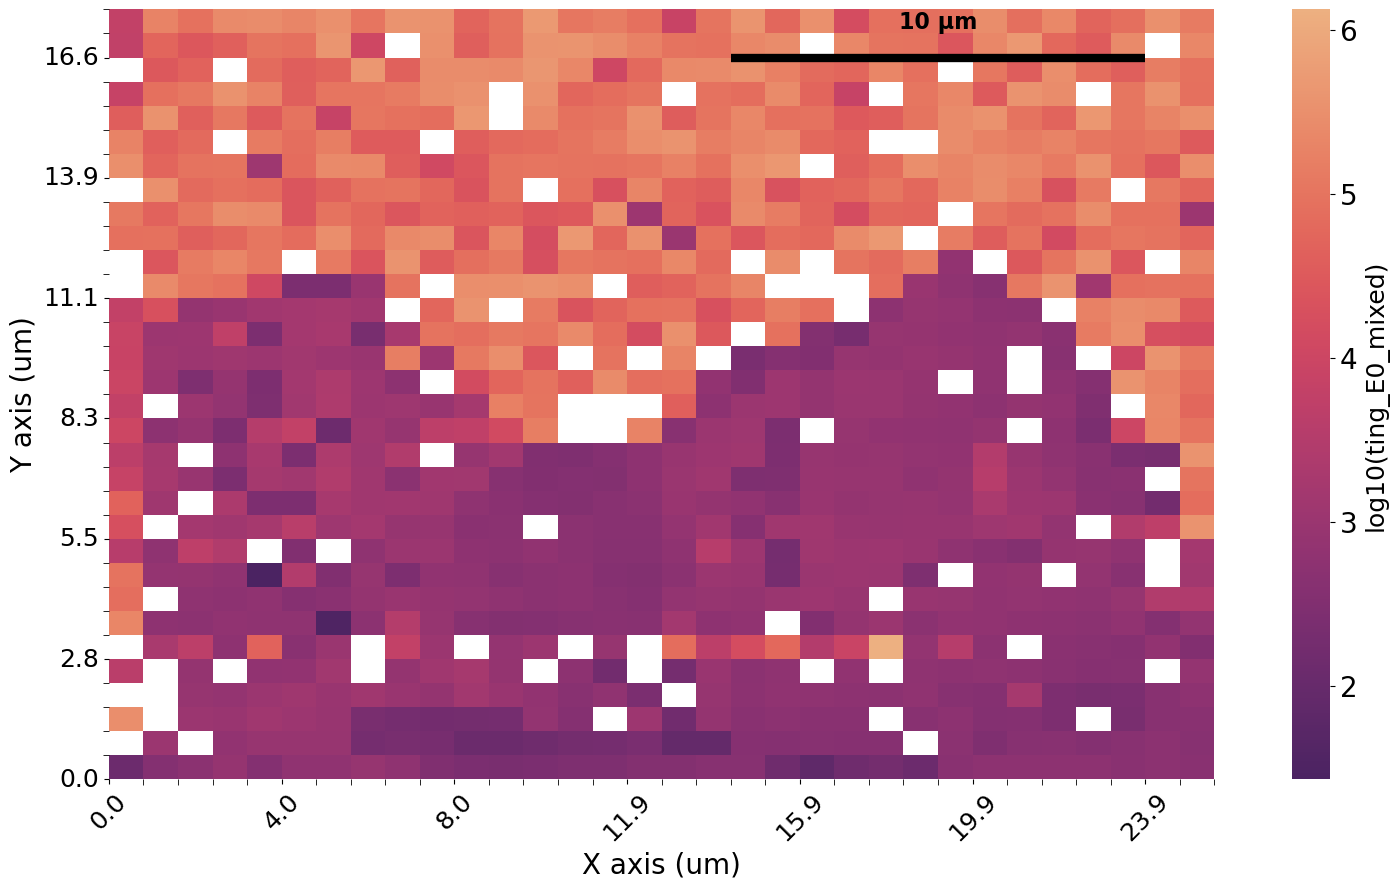

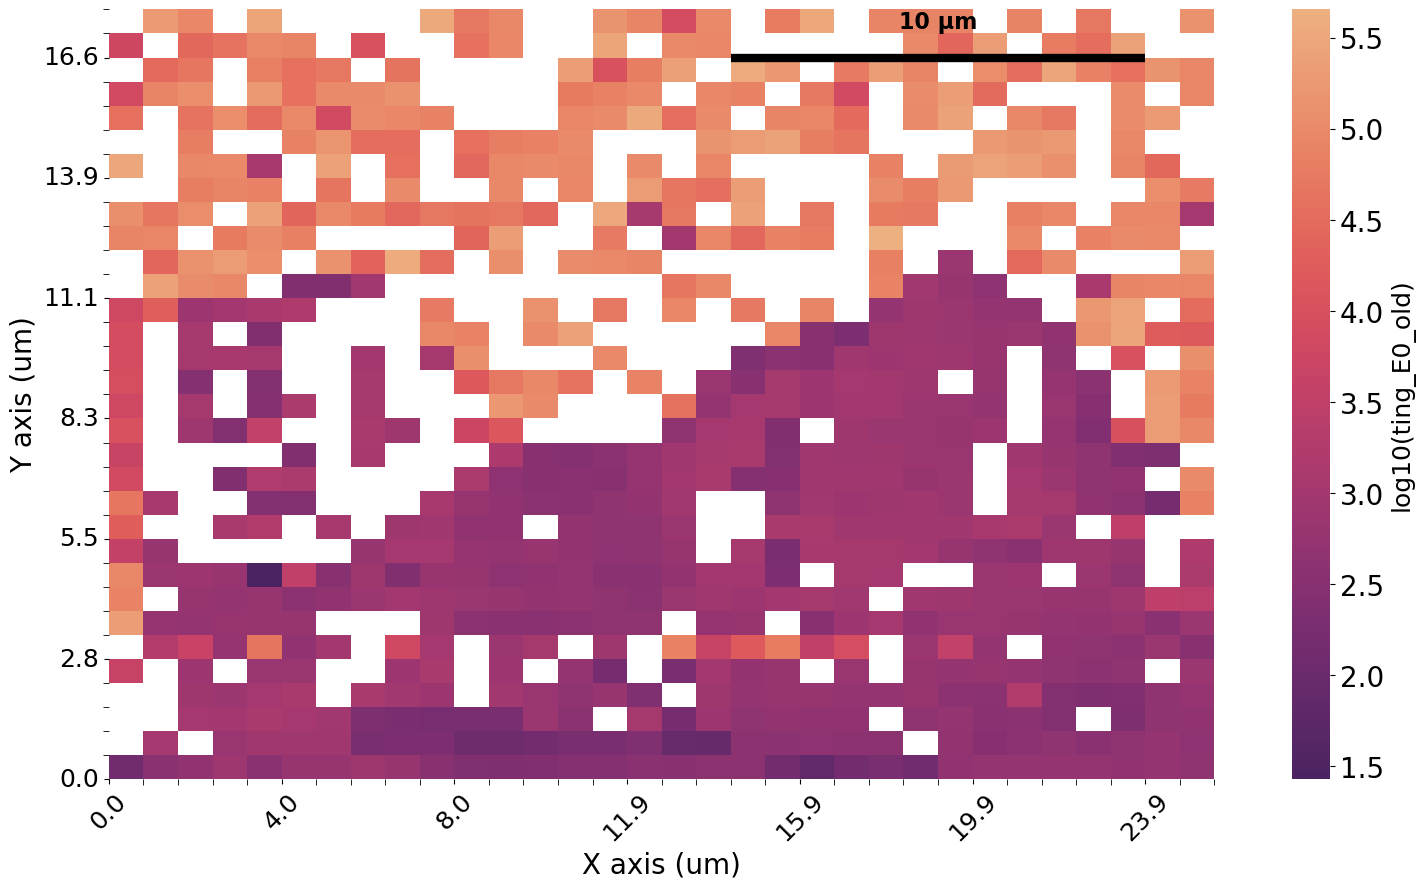

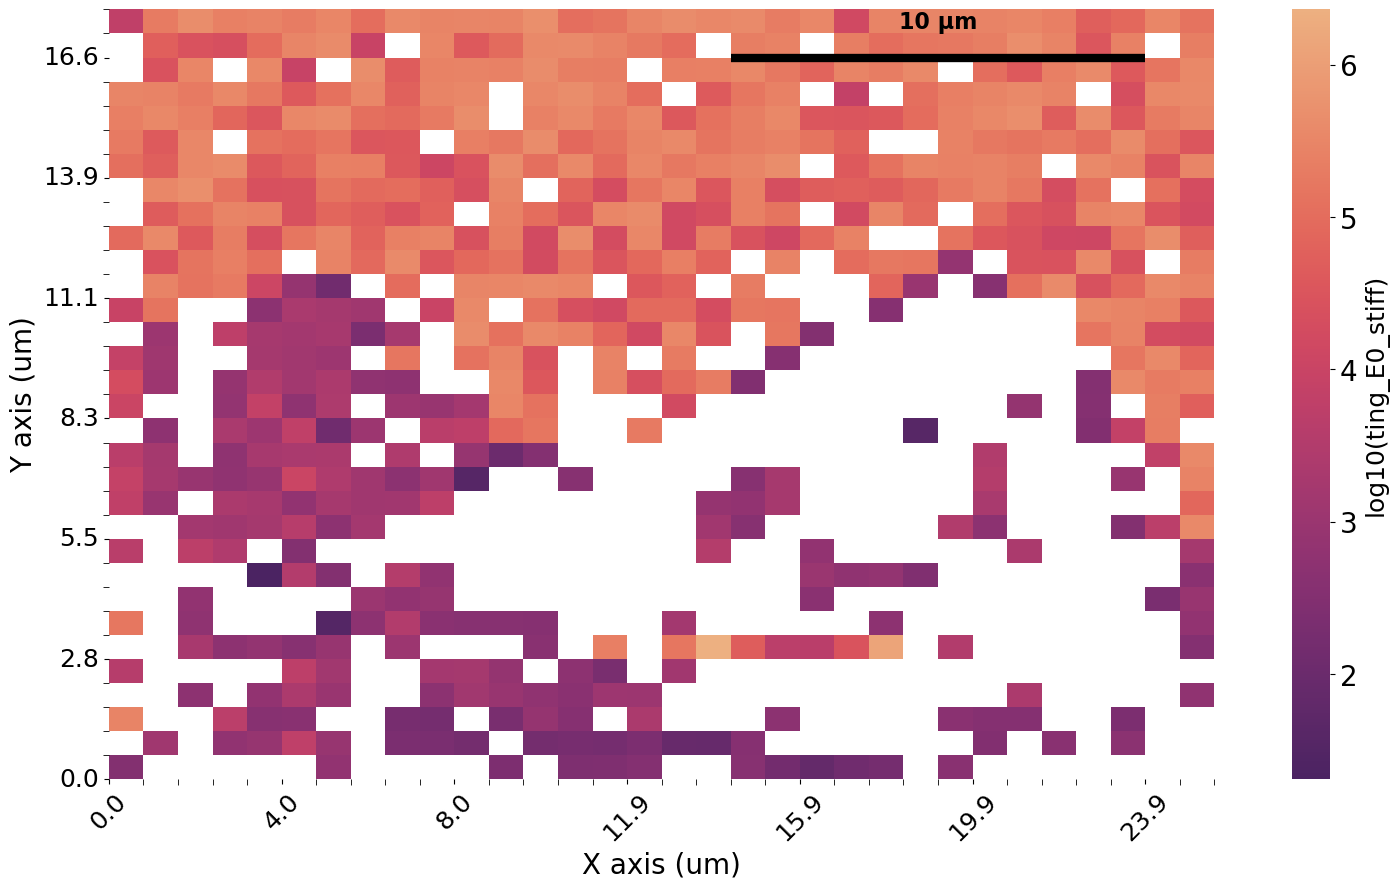

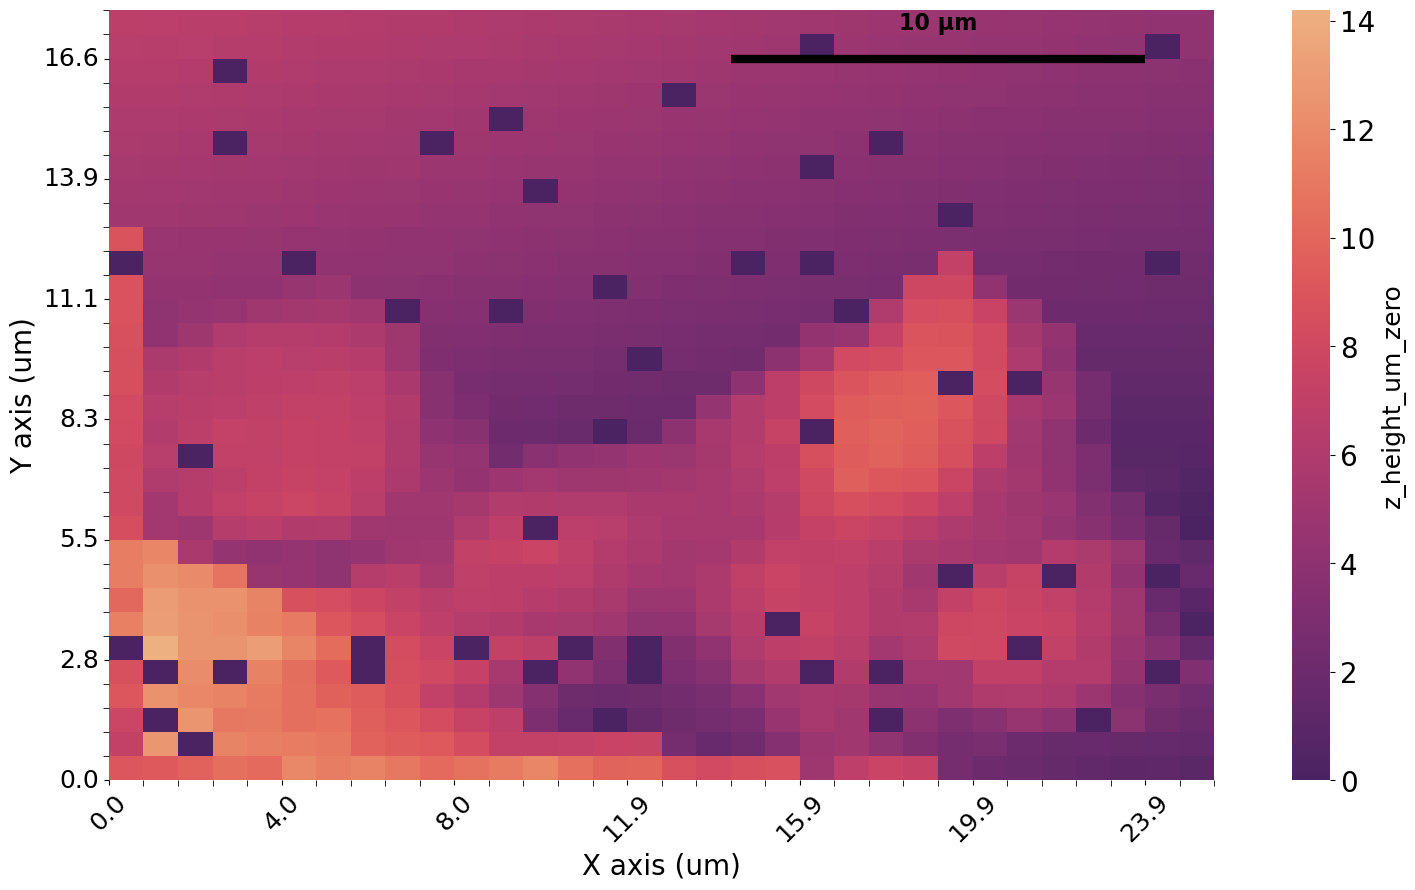

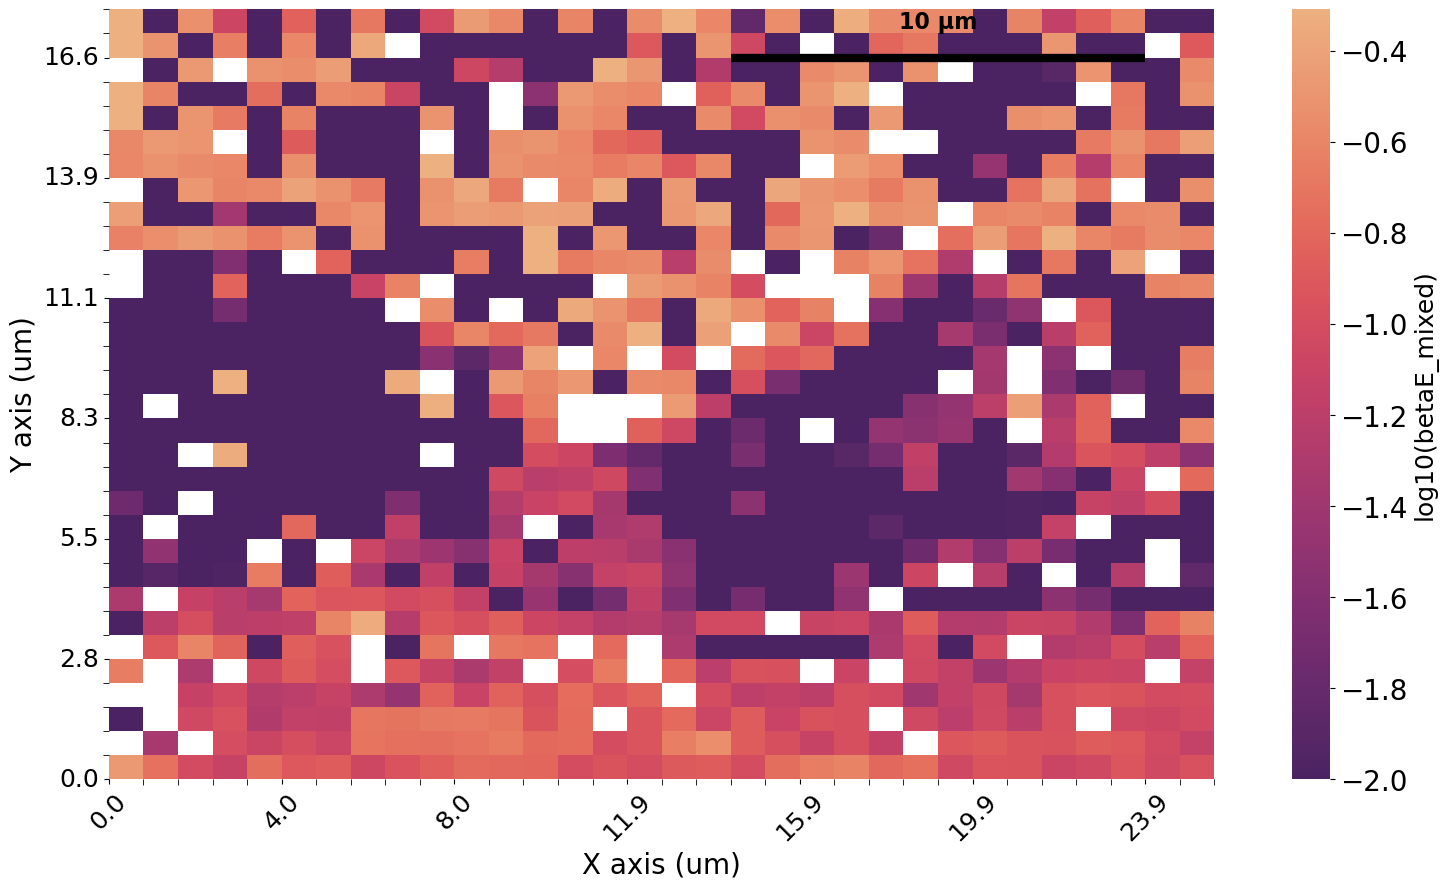

In [ ]:
keys_list = ['ting_E0_mixed', 'ting_E0_old', 'ting_E0_stiff', 'z_height_um_zero', 'betaE_mixed']
logscale = [True, True, True, False, True]



for key_combined, logscale_value in zip(keys_list, logscale):
    df_temp, _ , _ = maps.create_heatmap(df_final_ting, value_key=key_combined, annot=False,
                            save_svg=False, svg_path=os.path.join(map_file_path, f'{key_combined}_{map_name}.svg'),
                            cmap='flare_r', nan=True, lastColFirst=False, logscale=logscale_value, scale_axis=True)
    
    # save csv file for each map
    # print (f'Saving CSV for {key_combined}_{map_name}.csv')
    # df_temp.to_csv(os.path.join(csv_file_path, f'{key_combined}_{map_name}.csv'), index=False)
    # save corresponding dataframe as csv file with all rows and columsn from df_temp dataframe
    # df_temp.to_csv(os.path.join(csv_file_path, f'{key_combined}_{map_name}_full.csv'), index=False)

    # save svg file for each map
    
  


In [90]:
z_height_um_zero = df_final_ting['z_height_um_zero']    

Text(0, 0.5, 'Frequency')

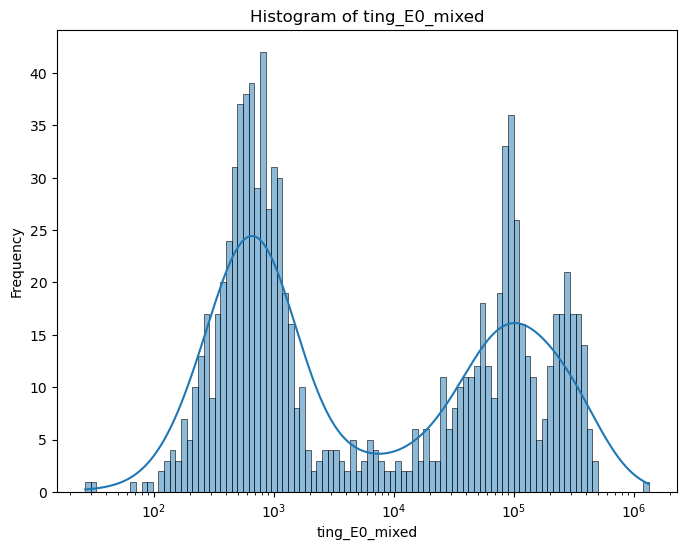

In [91]:
# plot histogram of ting_E0_mixed using seaborn. make x axis in logscale,
plt.figure(figsize=(8,6))
sns.histplot(df_final_ting['ting_E0_mixed'].dropna(), bins=100, kde=True, log_scale=True)
plt.title('Histogram of ting_E0_mixed')
plt.xlabel('ting_E0_mixed')
plt.ylabel('Frequency')         

Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 1, zmin: 0
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/CTC44/2025_12_03/svg_maps/E0_source_mask_psnex_map___2025.05.30_17.44.50.71.svg


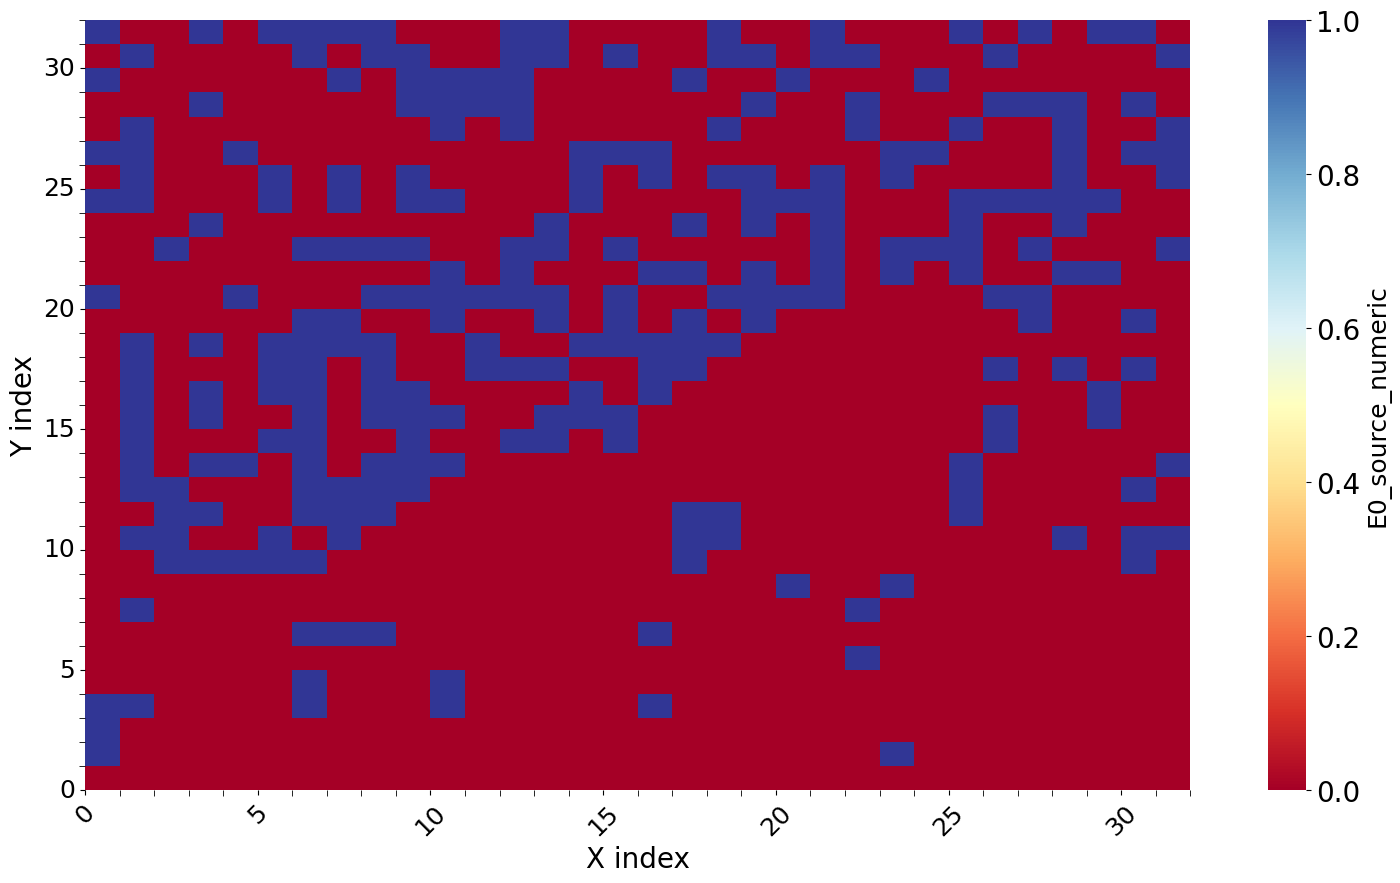

In [92]:

# Plot with binary colormap
_ = maps.create_heatmap(
    df_final_ting,
    value_key='E0_source_numeric', 
    annot=False,
    save_svg=True, 
    svg_path=os.path.join(svg_dir, f'E0_source_mask_{map_name}.svg'),
    cmap='RdYlBu',  # Red = old, Blue = stiff
    nan=False, 
    lastColFirst=False, 
    logscale=False,
    zmin=0,
    zmax=1
)